## pairwise alignment corona

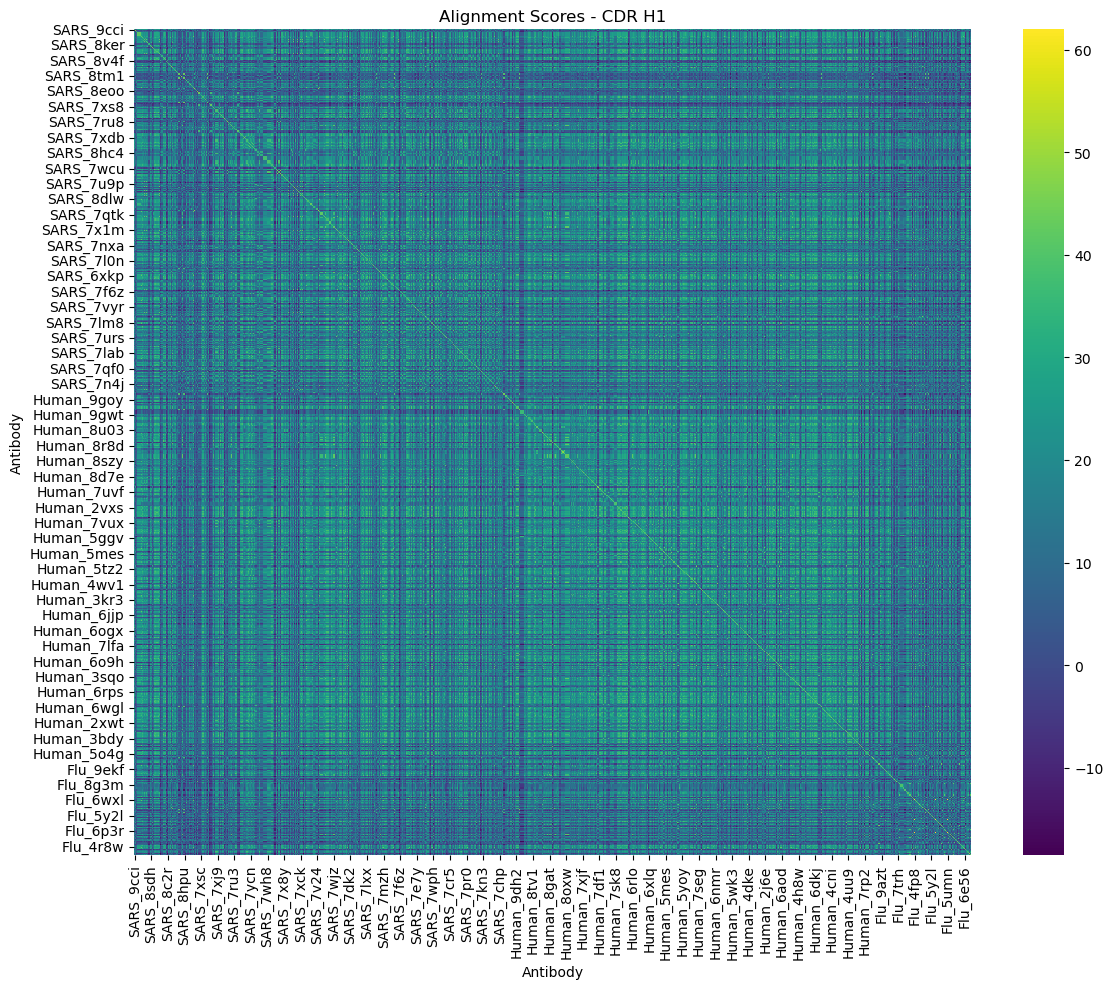

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Matrix einlesen
df = pd.read_csv(r"C:\Users\clara\group04-team02\archive\cdr_h1_alignment_matrix.tsv", sep="\t", index_col=0)

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df, cmap="viridis")
plt.title("Alignment Scores - CDR H1")
plt.xlabel("Antibody")
plt.ylabel("Antibody")
plt.tight_layout()
plt.show()


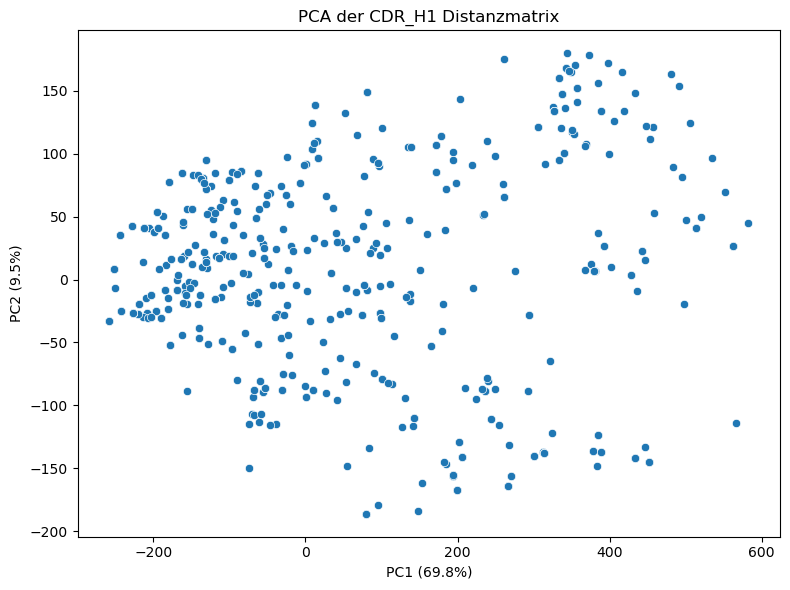

In [13]:
# 1. In Distanzen umwandeln (z.B. Max-Score - Score)
max_score = df.values.max()
distance_matrix = max_score - df

# 2. PCA auf Distanzen (nicht optimal, besser wäre MDS)
# Falls du PCA probierst:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(distance_matrix)

# 3. Plot
import seaborn as sns
import matplotlib.pyplot as plt

pca_df = pd.DataFrame(components, columns=["PC1", "PC2"], index=df.index)
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", data=pca_df)
plt.title("PCA der CDR_H1 Distanzmatrix")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()


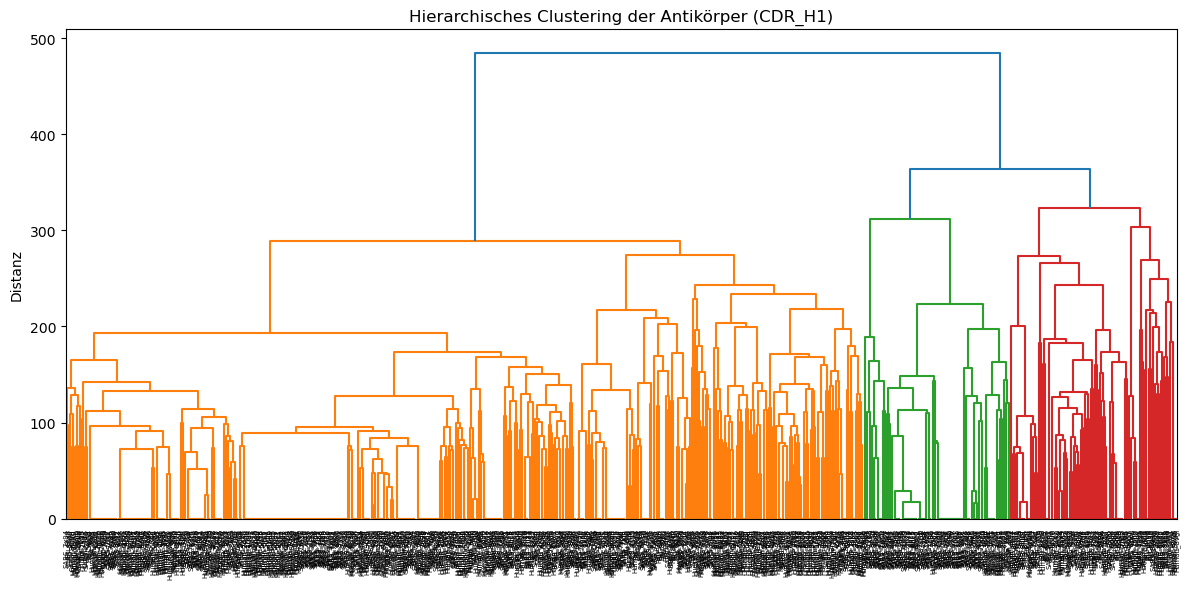

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Hier nehmen wir wieder Distanzen
linked = linkage(distance_matrix, method="average")

plt.figure(figsize=(12,6))
dendrogram(linked, labels=df.index, leaf_rotation=90)
plt.title("Hierarchisches Clustering der Antikörper (CDR_H1)")
plt.ylabel("Distanz")
plt.tight_layout()
plt.show()


In [17]:
from scipy.cluster.hierarchy import fcluster

# Nehmen wir an: linkage-Objekt heißt "linked"
# threshold=200 ist ein Beispiel, kann angepasst werden
cluster_labels = fcluster(linked, t=200, criterion='distance')

# Zu DataFrame
df_clusters = pd.DataFrame({
    'ID': df.index,
    'Cluster': cluster_labels
})


In [18]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# Clusterlabels berechnen
cluster_labels = fcluster(linked, t=200, criterion='distance')

# MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(distance_matrix)

# DataFrame
mds_df = pd.DataFrame(coords, columns=["Dim1", "Dim2"])
mds_df["Cluster"] = cluster_labels
mds_df["ID"] = df.index


c:\Users\clara\anaconda3\envs\group2\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


In [21]:
# 1) Alignment-Score-Matrix laden
df = pd.read_csv(r"C:\Users\clara\group04-team02\archive\cdr_h1_alignment_matrix.tsv", sep="\t", index_col=0)

# 2) Distanzmatrix definieren (max - score)
max_score = df.values.max()
distance_matrix = max_score - df.values

# 3) Diagonale explizit auf 0 setzen
np.fill_diagonal(distance_matrix, 0)

# 4) squareform() konvertieren
from scipy.spatial.distance import squareform
condensed_distances = squareform(distance_matrix)

# 5) linkage
from scipy.cluster.hierarchy import linkage, fcluster
linked = linkage(condensed_distances, method="ward")

# 6) Clusterlabels
cluster_labels = fcluster(linked, t=200, criterion='distance')



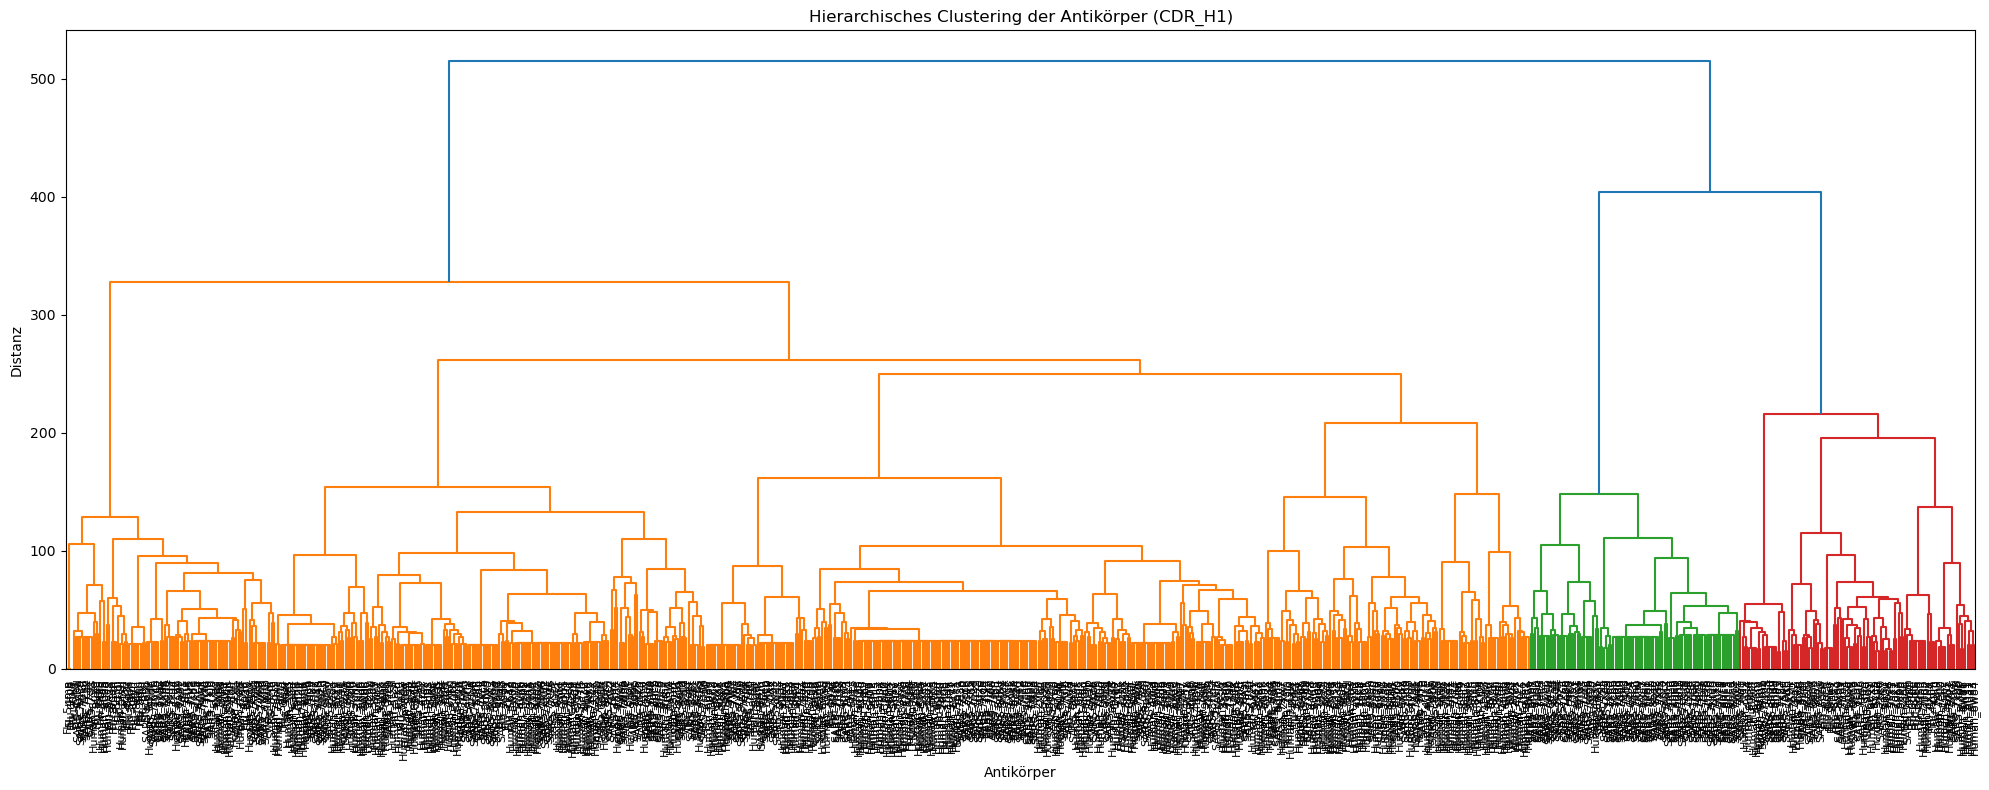

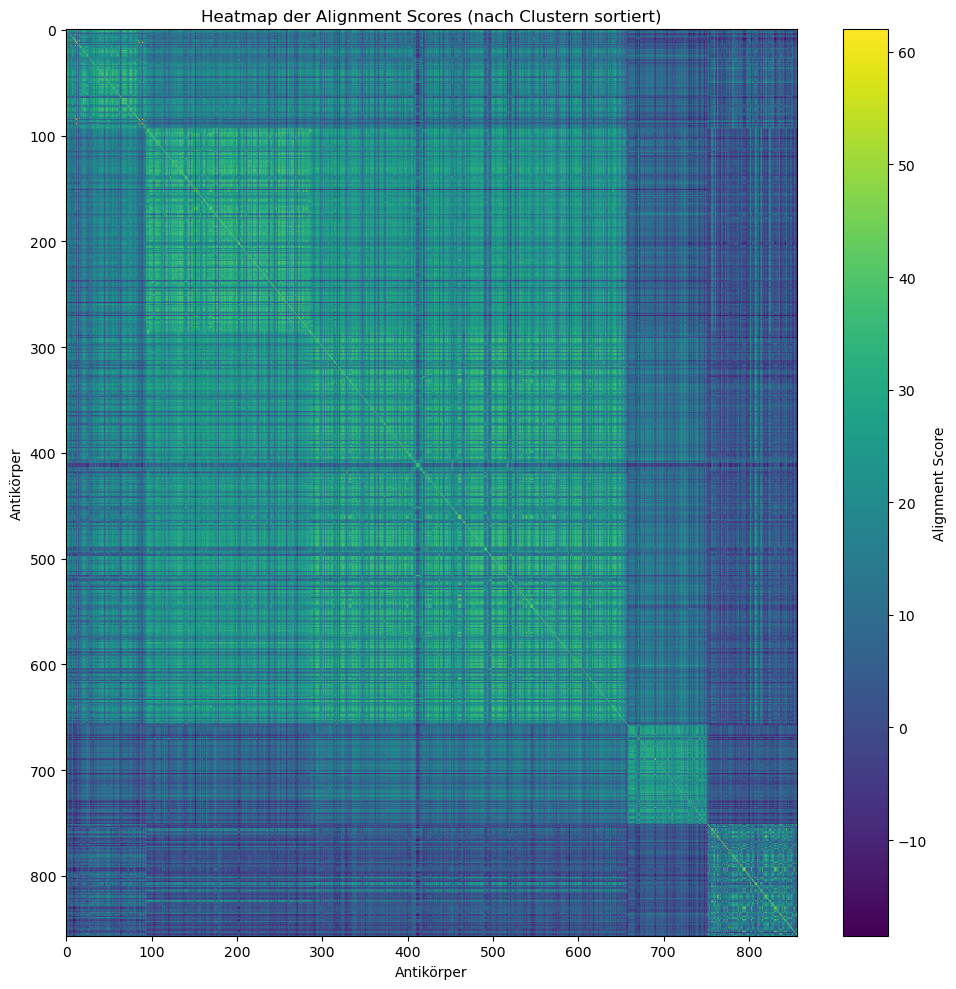

In [23]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# 1) Matrix laden
df = pd.read_csv(r"C:\Users\clara\group04-team02\archive\cdr_h1_alignment_matrix.tsv", sep="\t", index_col=0)

# 2) Distanzmatrix erstellen
max_score = df.values.max()
distance_matrix = max_score - df.values
np.fill_diagonal(distance_matrix, 0)

# 3) squareform konvertieren
condensed = squareform(distance_matrix)

# 4) linkage
linked = linkage(condensed, method="ward")

# 5) Clusterlabels
n_clusters = 5
cluster_labels = fcluster(linked, t=n_clusters, criterion="maxclust")

# 6) Dendrogramm
plt.figure(figsize=(20, 8))
dendrogram(
    linked,
    labels=df.index,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=None
)
plt.title("Hierarchisches Clustering der Antikörper (CDR_H1)")
plt.xlabel("Antikörper")
plt.ylabel("Distanz")
plt.tight_layout()
plt.show()

# 7) Heatmap nach Clusterlabels sortiert
# Zeilen/Spalten nach Cluster sortieren
sorted_indices = np.argsort(cluster_labels)
sorted_df = df.iloc[sorted_indices, :].iloc[:, sorted_indices]

plt.figure(figsize=(10, 10))
plt.imshow(sorted_df.values, cmap="viridis", aspect="auto")
plt.colorbar(label="Alignment Score")
plt.title("Heatmap der Alignment Scores (nach Clustern sortiert)")
plt.xlabel("Antikörper")
plt.ylabel("Antikörper")
plt.tight_layout()
plt.show()


In [24]:
for idx, label in enumerate(df.index):
    print(f"{label}: Cluster {cluster_labels[idx]}")


SARS_9cci: Cluster 3
SARS_9ccj: Cluster 5
SARS_9bj2: Cluster 4
SARS_8z6r: Cluster 2
SARS_8z6s: Cluster 2
SARS_8z6t: Cluster 2
SARS_8z6x: Cluster 2
SARS_8v5v: Cluster 2
SARS_9c44: Cluster 3
SARS_8s6m: Cluster 3
SARS_8wpw: Cluster 2
SARS_9atm: Cluster 3
SARS_9au1: Cluster 2
SARS_8kdm: Cluster 3
SARS_8keo: Cluster 3
SARS_8kep: Cluster 3
SARS_8ker: Cluster 3
SARS_8sdh: Cluster 3
SARS_8vcr: Cluster 5
SARS_8yww: Cluster 3
SARS_8q5y: Cluster 3
SARS_8xse: Cluster 3
SARS_8xsf: Cluster 3
SARS_8xsi: Cluster 3
SARS_8xsj: Cluster 3
SARS_8y6a: Cluster 2
SARS_8c0y: Cluster 4
SARS_8qh0: Cluster 4
SARS_8qh1: Cluster 4
SARS_8hlc: Cluster 3
SARS_8hld: Cluster 2
SARS_8p5m: Cluster 3
SARS_8v4f: Cluster 4
SARS_8x0y: Cluster 5
SARS_8c2r: Cluster 4
SARS_8xi6: Cluster 2
SARS_8khc: Cluster 3
SARS_8vye: Cluster 3
SARS_8r1c: Cluster 5
SARS_8sdf: Cluster 2
SARS_8sdg: Cluster 3
SARS_8siq: Cluster 3
SARS_8sit: Cluster 3
SARS_8cin: Cluster 1
SARS_8cbf: Cluster 1
SARS_8hp9: Cluster 5
SARS_8hpq: Cluster 5
SARS_8hpv: Cl

In [25]:
cluster_df = pd.DataFrame({
    "PDB": df.index,
    "Cluster": cluster_labels
}).sort_values("Cluster")
print(cluster_df)


           PDB  Cluster
856   Flu_3gbn        1
854   Flu_6lxi        1
853   Flu_5vag        1
852   Flu_5gjs        1
846   Flu_4o58        1
..         ...      ...
45   SARS_8hp9        5
319  SARS_7xh8        5
306  SARS_7wph        5
837   Flu_6q0e        5
18   SARS_8vcr        5

[857 rows x 2 columns]


In [27]:
print(cluster_df.query("Cluster == 1"))



           PDB  Cluster
856   Flu_3gbn        1
854   Flu_6lxi        1
853   Flu_5vag        1
852   Flu_5gjs        1
846   Flu_4o58        1
..         ...      ...
820   Flu_6ml8        1
282  SARS_7msq        1
288  SARS_7vyr        1
315  SARS_7kqe        1
299  SARS_7m3i        1

[94 rows x 2 columns]


c:\Users\clara\anaconda3\envs\group2\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


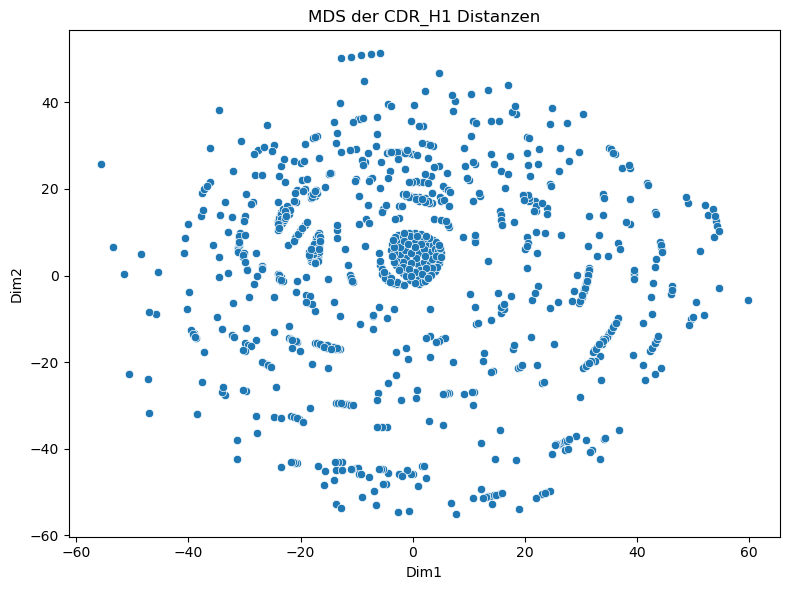

In [15]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(distance_matrix)

mds_df = pd.DataFrame(coords, columns=["Dim1", "Dim2"], index=df.index)

plt.figure(figsize=(8,6))
sns.scatterplot(x="Dim1", y="Dim2", data=mds_df)
plt.title("MDS der CDR_H1 Distanzen")
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
from Bio import pairwise2

# Lies deine Tabelle ein
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

# Wir nehmen z.B. die Spalte 'CDR_H1' zum pairwise Vergleichen
cdr_column = 'CDR_H1'

# Optional: Filtere leere oder fehlende Sequenzen raus
data = data[data[cdr_column].notnull()]

# Liste für Scores
scores = []

# Alle pairwise alignments innerhalb der CDR_H1-Spalte
for i in range(len(data)):
    for j in range(i+1, len(data)):
        seq1 = data.iloc[i][cdr_column]
        seq2 = data.iloc[j][cdr_column]
        
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]  # alignment score
            scores.append(score)
            
            # Hier wird der Score sofort in eine Datei geschrieben:
            with open('scores_CDR_H1.txt', 'a') as f:
                f.write(f"{i},{j},{score}\n")



c:\Users\clara\anaconda3\envs\group2\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: 'sars_cov2_cdr_seq.tsv'

In [2]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


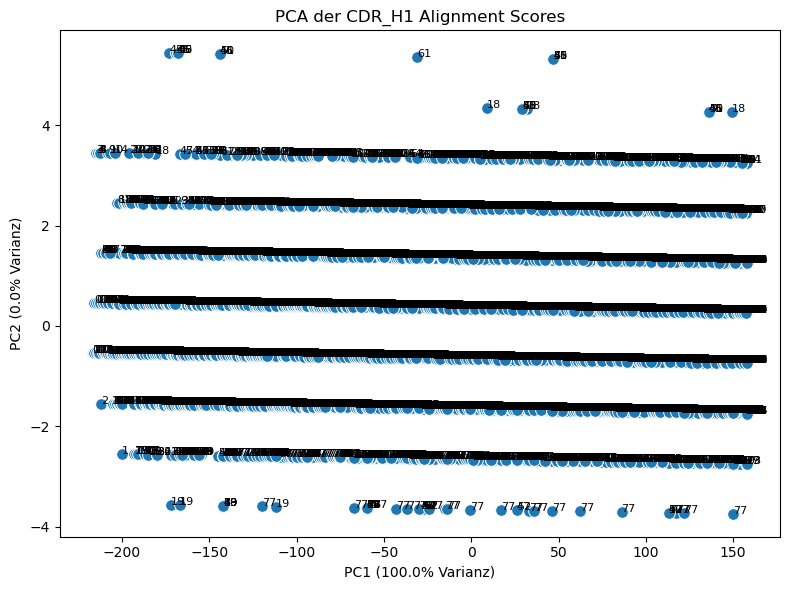

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Matrix einlesen
df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\scores_CDR_H1.txt", index_col=0)

# 2. Falls gewünscht: symmetrische Matrix prüfen
# (nur zur Sicherheit, kann sonst weggelassen werden)
# assert np.allclose(df.values, df.values.T), "Matrix ist nicht symmetrisch"

# 3. PCA vorbereiten
# Hinweis: PCA braucht Samples als Zeilen und Features als Spalten
# Wir nehmen hier einfach die Matrixzeilen als Features (jede Sequenz = Sample)
X = df.values

# 4. PCA ausführen
pca = PCA(n_components=2)
components = pca.fit_transform(X)

# 5. Ergebnisse in DataFrame packen
pca_df = pd.DataFrame(components, columns=["PC1", "PC2"], index=df.index)

# 6. Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", data=pca_df, s=70)

# IDs annotieren
for i, txt in enumerate(pca_df.index):
    plt.annotate(txt, (pca_df.iloc[i,0], pca_df.iloc[i,1]), fontsize=8)


plt.title("PCA der CDR_H1 Alignment Scores")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.tight_layout()
plt.show()


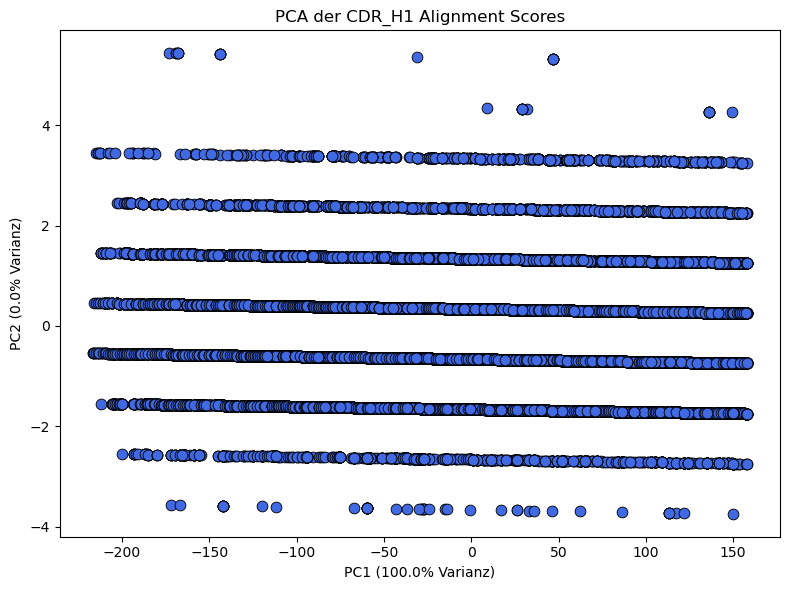

In [9]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Matrix einlesen
df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\scores_CDR_H1.txt", index_col=0)

# 3. PCA vorbereiten
X = df.values

# 4. PCA ausführen
pca = PCA(n_components=2)
components = pca.fit_transform(X)

# 5. Ergebnisse in DataFrame
pca_df = pd.DataFrame(components, columns=["PC1", "PC2"], index=df.index)

# 6. Nur Punkte plotten (kein Text)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    data=pca_df,
    s=60,
    color="royalblue",
    edgecolor="black"
)

plt.title("PCA der CDR_H1 Alignment Scores")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.tight_layout()
plt.show()


In [5]:
from sklearn.manifold import MDS
import pandas as pd

# D = Distanzmatrix (z.B. 1 - Ähnlichkeitsscores, falls nötig)
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(df.values)

# Ergebnis als DataFrame
mds_df = pd.DataFrame(coords, columns=["Dim1", "Dim2"], index=df.index)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(mds_df["Dim1"], mds_df["Dim2"])

for i, txt in enumerate(mds_df.index):
    plt.annotate(txt, (mds_df.iloc[i,0], mds_df.iloc[i,1]), fontsize=8)

plt.title("MDS der CDR_H1 Distanzmatrix")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()


c:\Users\clara\anaconda3\envs\group2\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


ValueError: array must be 2-dimensional and square. shape = (40681, 2)

In [ ]:
import numpy as np

scores = []

# Read the file and extract scores
cdr_column = 'CDR_H1'  # Use the same column name as before

with open(f'scores_{cdr_column}.txt', 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        score = float(parts[2])
        scores.append(score)

# Calculate average
if scores:
    average_score = np.mean(scores)
    print(f"Average alignment score for {cdr_column}: {average_score:.2f}")
else:
    print("No scores found.")



Average alignment score for CDR_H1: 3.72


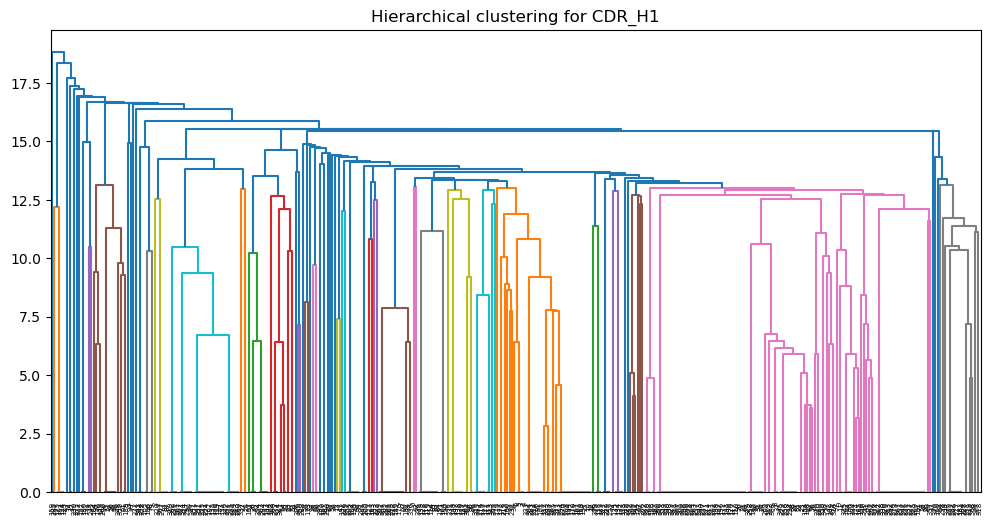

In [ ]:
import pandas as pd
import numpy as np
from Bio import pairwise2
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Load your table
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

cdr_column = 'CDR_H1'
data = data[data[cdr_column].notnull()]
data = data.reset_index(drop=True)  # reset indices after filtering

num_sequences = len(data)
# Initialize a similarity matrix
similarity_matrix = np.zeros((num_sequences, num_sequences))

# Compute pairwise alignment scores
for i in range(num_sequences):
    for j in range(i, num_sequences):
        seq1 = data.loc[i, cdr_column]
        seq2 = data.loc[j, cdr_column]
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]
            similarity_matrix[i, j] = score
            similarity_matrix[j, i] = score  # matrix is symmetric

# Now turn similarity into distance (simple way: max_score - score)
max_score = np.max(similarity_matrix)
distance_matrix = max_score - similarity_matrix

# Perform hierarchical clustering
linked = linkage(distance_matrix, 'single')  # you can also try 'complete', 'average', etc.

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=data.index)
plt.title(f"Hierarchical clustering for {cdr_column}")
plt.show()


#### das ist ultra trash sorry

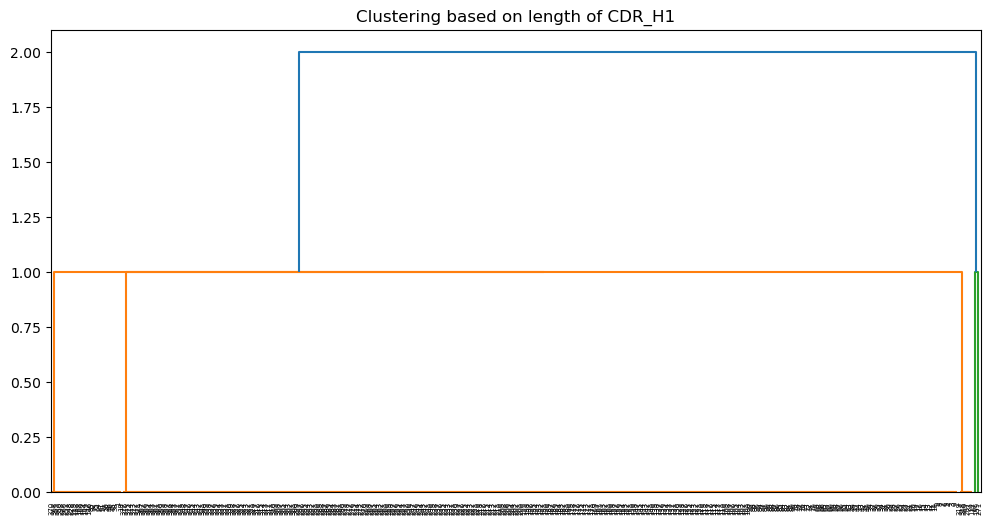

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

cdr_column = 'CDR_H1'
data = data[data[cdr_column].notnull()]
data = data.reset_index(drop=True)

# Extract sequence lengths
data['length'] = data[cdr_column].apply(len)

# You can also use other features later (e.g. AA composition etc.)

# Reshape into correct form for clustering
lengths = data['length'].values.reshape(-1, 1)

# Hierarchical clustering
linked = linkage(lengths, 'single')

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=data.index)
plt.title(f"Clustering based on length of {cdr_column}")
plt.show()

In [10]:
import pandas as pd
from Bio import pairwise2

# Lies deine Tabelle ein
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

# Wir nehmen z.B. die Spalte 'CDR_H2' zum pairwise Vergleichen
cdr_column = 'CDR_H2'

# Optional: Filtere leere oder fehlende Sequenzen raus
data = data[data[cdr_column].notnull()]

# Liste für Scores
scores = []

# Alle pairwise alignments innerhalb der CDR_H2-Spalte
for i in range(len(data)):
    for j in range(i+1, len(data)):
        seq1 = data.iloc[i][cdr_column]
        seq2 = data.iloc[j][cdr_column]
        
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]  # alignment score
            scores.append(score)
            
            # Hier wird der Score sofort in eine Datei geschrieben:
            with open('scores_CDR_H2.txt', 'a') as f:
                f.write(f"{i},{j},{score}\n")


c:\Users\clara\anaconda3\envs\group2\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: 'sars_cov2_cdr_seq.tsv'

In [ ]:
import numpy as np

scores = []

# Read the file and extract scores
cdr_column = 'CDR_H2'  # Use the same column name as before

with open(f'scores_{cdr_column}.txt', 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        score = float(parts[2])
        scores.append(score)

# Calculate average
if scores:
    average_score = np.mean(scores)
    print(f"Average alignment score for {cdr_column}: {average_score:.2f}")
else:
    print("No scores found.")


Average alignment score for CDR_H2: 2.24


In [ ]:
import pandas as pd
from Bio import pairwise2

# Load your table
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

# Select the CDR column you want to analyze
cdr_column = 'CDR_H3'  # Now we analyze CDR_H3

# Filter out missing or empty sequences
data = data[data[cdr_column].notnull()]

# List to store alignment scores (optional)
scores = []

# Perform pairwise alignments within the CDR_H3 column
for i in range(len(data)):
    for j in range(i+1, len(data)):
        seq1 = data.iloc[i][cdr_column]
        seq2 = data.iloc[j][cdr_column]
        
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]  # alignment score
            scores.append(score)
            
            # Save the score directly into a file
            with open('scores_CDR_H3.txt', 'a') as f:
                f.write(f"{i},{j},{score}\n")


In [ ]:
import numpy as np

scores = []

# Read the file and extract scores
cdr_column = 'CDR_H3'  # Use the same column name as before

with open(f'scores_{cdr_column}.txt', 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        score = float(parts[2])
        scores.append(score)

# Calculate average
if scores:
    average_score = np.mean(scores)
    print(f"Average alignment score for {cdr_column}: {average_score:.2f}")
else:
    print("No scores found.")


Average alignment score for CDR_H3: 4.56


#### normalization alignment scores 

Mean normalized score: 0.5133656137898065


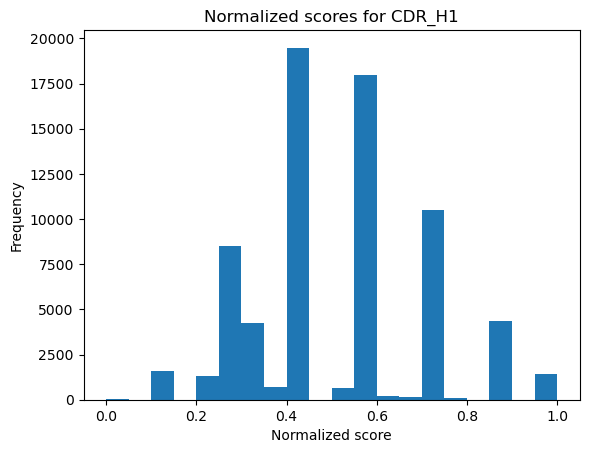

In [ ]:
import pandas as pd

# Load your original sequences
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')
cdr_column = 'CDR_H1'
data = data[data[cdr_column].notnull()].reset_index(drop=True)

# Compute sequence lengths
data['seq_length'] = data[cdr_column].apply(len)

# Load the scores file
scores_df = pd.read_csv('scores_CDR_H1.txt', header=None, names=['i', 'j', 'score'])

# Normalize
def normalize(row):
    len_i = data.loc[row['i'], 'seq_length']
    len_j = data.loc[row['j'], 'seq_length']
    max_len = max(len_i, len_j)
    return row['score'] / max_len

scores_df['normalized_score'] = scores_df.apply(normalize, axis=1)

# Save normalized file for future fast use
scores_df.to_csv('normalized_scores_CDR_H1.txt', index=False)

# Quick summary
print(f"Mean normalized score: {scores_df['normalized_score'].mean()}")

# Optional: plot
import matplotlib.pyplot as plt

plt.hist(scores_df['normalized_score'], bins=20)
plt.title('Normalized scores for CDR_H1')
plt.xlabel('Normalized score')
plt.ylabel('Frequency')
plt.show()


Mean normalized score: 0.3833336173648161


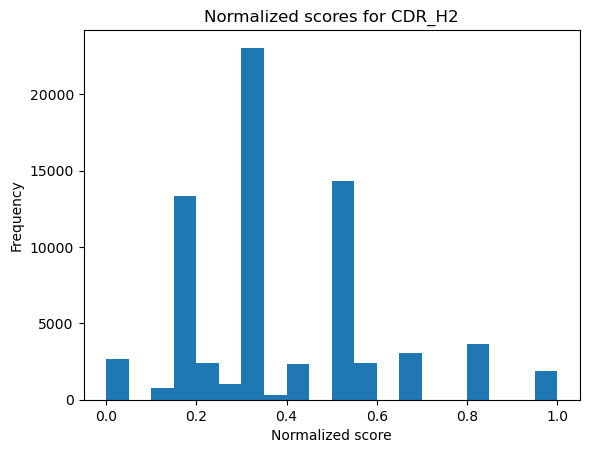

In [ ]:
import pandas as pd

# Load your original sequences
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')
cdr_column = 'CDR_H2'
data = data[data[cdr_column].notnull()].reset_index(drop=True)

# Compute sequence lengths
data['seq_length'] = data[cdr_column].apply(len)

# Load the scores file
scores_df = pd.read_csv('scores_CDR_H2.txt', header=None, names=['i', 'j', 'score'])

# Normalize
def normalize(row):
    len_i = data.loc[row['i'], 'seq_length']
    len_j = data.loc[row['j'], 'seq_length']
    max_len = max(len_i, len_j)
    return row['score'] / max_len

scores_df['normalized_score'] = scores_df.apply(normalize, axis=1)

# Save normalized file for future fast use
scores_df.to_csv('normalized_scores_CDR_H2.txt', index=False)

# Quick summary
print(f"Mean normalized score: {scores_df['normalized_score'].mean()}")

# Optional: plot
import matplotlib.pyplot as plt

plt.hist(scores_df['normalized_score'], bins=20)
plt.title('Normalized scores for CDR_H2')
plt.xlabel('Normalized score')
plt.ylabel('Frequency')
plt.show()


Mean normalized score: 0.30362870106096745


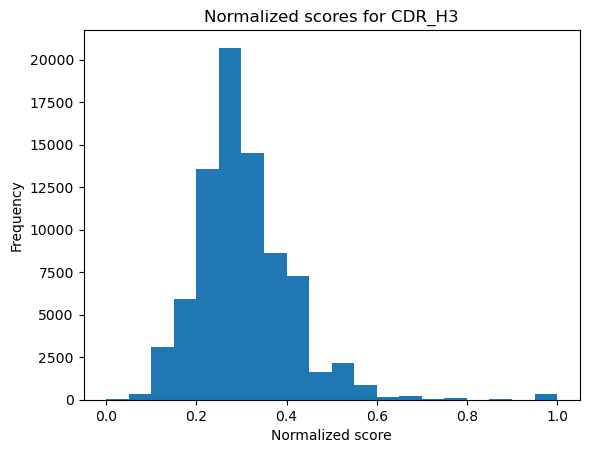

In [ ]:
import pandas as pd
from Bio import pairwise2

data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')
cdr_column = 'CDR_H3'
data = data[data[cdr_column].notnull()]
scores = []

for i in range(len(data)):
    for j in range(i+1, len(data)):
        seq1 = data.iloc[i][cdr_column]
        seq2 = data.iloc[j][cdr_column]
        
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]  # raw score (number of matches)
            alignment_length = max(len(seq1), len(seq2))  # simple approximation
            normalized_score = score / alignment_length
            scores.append(normalized_score)
            
            with open('normalized_scores_CDR_H3.txt', 'a') as f:
                f.write(f"{i},{j},{normalized_score}\n")


C:\Users\clara\AppData\Local\Temp\ipykernel_16524\1000445293.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_scores, x='CDR', y='normalized_score', palette='Set2')


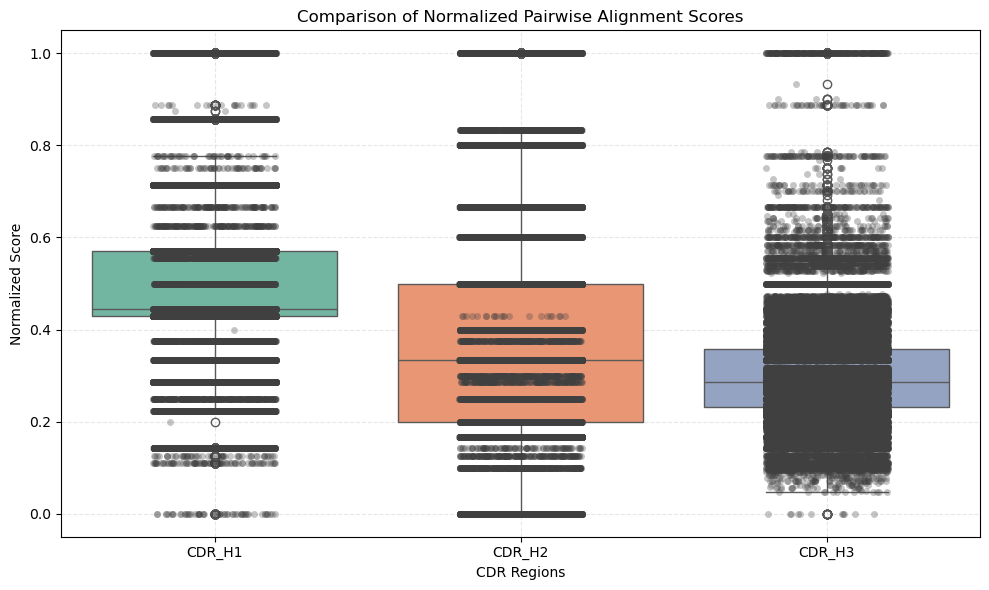

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read normalized score files
h1 = pd.read_csv('normalized_scores_CDR_H1.txt')
h2 = pd.read_csv('normalized_scores_CDR_H2.txt')
h3 = pd.read_csv('normalized_scores_CDR_H3.txt')

# Add CDR type columns
h1['CDR'] = 'CDR_H1'
h2['CDR'] = 'CDR_H2'
h3['CDR'] = 'CDR_H3'

# Combine into one DataFrame
all_scores = pd.concat([h1, h2, h3])

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=all_scores, x='CDR', y='normalized_score', palette='Set2')

# Optional: fast scatterplot instead of heavy swarmplot
sns.stripplot(data=all_scores, x='CDR', y='normalized_score', 
              color=".25", alpha=0.3, jitter=0.2)

plt.title('Comparison of Normalized Pairwise Alignment Scores')
plt.ylabel('Normalized Score')
plt.xlabel('CDR Regions')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


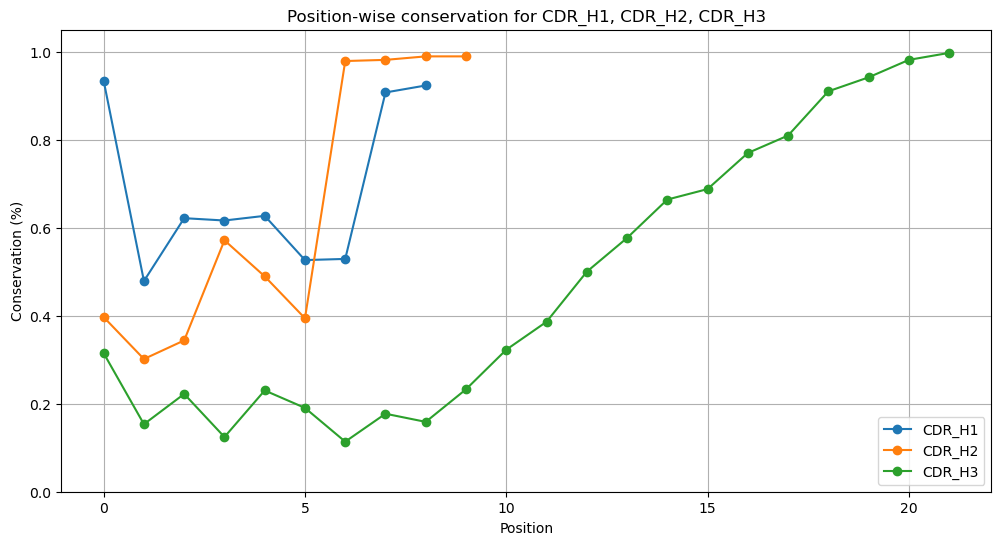

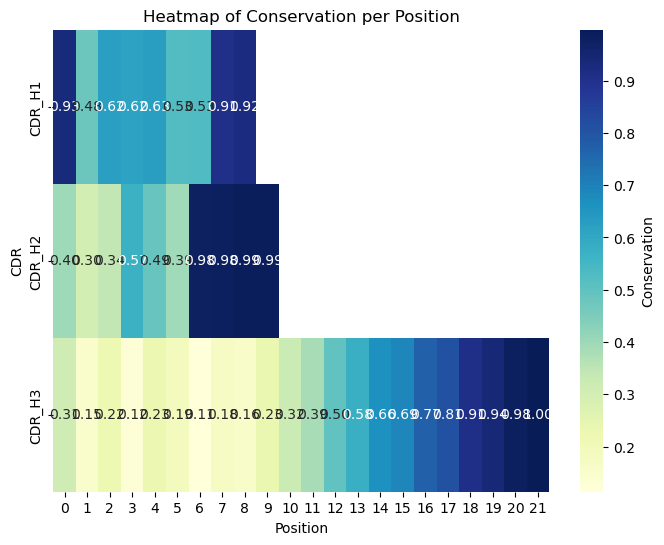

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the full table
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

# Choose your CDR columns
cdr_columns = ['CDR_H1', 'CDR_H2', 'CDR_H3']

# Dictionary to store conservation profiles
conservation_profiles = {}

for cdr in cdr_columns:
    # Filter missing sequences
    cdr_data = data[data[cdr].notnull()].reset_index(drop=True)
    
    # Find the longest sequence length
    max_len = cdr_data[cdr].apply(len).max()
    
    # Pad sequences with gaps to equal length
    padded_seqs = cdr_data[cdr].apply(lambda x: x.ljust(max_len, '-'))
    
    # Build sequence matrix
    seq_matrix = np.array([list(seq) for seq in padded_seqs])
    
    # Compute conservation per position
    conservation = []
    for col in seq_matrix.T:
        unique, counts = np.unique(col, return_counts=True)
        most_common_freq = counts.max() / counts.sum()
        conservation.append(most_common_freq)
    
    conservation_profiles[cdr] = conservation

# ---------- Combined Conservation Plot ----------
plt.figure(figsize=(12, 6))

for cdr in cdr_columns:
    plt.plot(conservation_profiles[cdr], marker='o', label=cdr)

plt.title("Position-wise conservation for CDR_H1, CDR_H2, CDR_H3")
plt.xlabel("Position")
plt.ylabel("Conservation (%)")
plt.ylim(0, 1.05)
plt.legend()
plt.grid()
plt.show()


# ---------- Heatmap ----------
# We need to align the length (pad shorter CDRs with NaNs)
max_total_len = max(len(conservation_profiles[cdr]) for cdr in cdr_columns)

heatmap_data = pd.DataFrame({
    cdr: conservation_profiles[cdr] + [np.nan]*(max_total_len - len(conservation_profiles[cdr]))
    for cdr in cdr_columns
})

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data.T, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={'label': 'Conservation'})
plt.title("Heatmap of Conservation per Position")
plt.xlabel("Position")
plt.ylabel("CDR")
plt.show()j


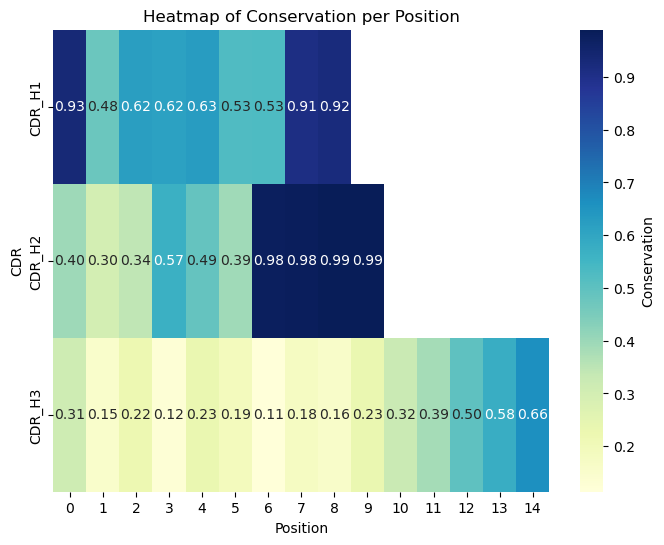

In [ ]:
max_length = 15
heatmap_data = pd.DataFrame({
    cdr: (conservation_profiles[cdr][:max_length] + [np.nan]*(max_length - len(conservation_profiles[cdr])))
    for cdr in cdr_columns
})
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data.T, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={'label': 'Conservation'})
plt.title("Heatmap of Conservation per Position")
plt.xlabel("Position")
plt.ylabel("CDR")
plt.show()



also weil es halt für längere CDRs weniger samples gibt, sind die daten nicht so biologisch relevant, versuche das zu fixen :))

In [4]:
import pandas as pd
from Bio import AlignIO, SeqIO
from Bio.Align.Applications import ClustalOmegaCommandline
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# === 1. Load your CDR_H3 sequences ===
data = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\human_cdr_seq.tsv", sep='\t')
cdr_column = 'CDR_H3'
data = data[data[cdr_column].notnull()]
data = data.reset_index(drop=True)

# === 2. Write sequences to FASTA file ===
records = []
for i, seq in enumerate(data[cdr_column]):
    records.append(SeqRecord(Seq(seq), id=f"Seq{i}", description=""))

SeqIO.write(records, "cdr_h3_sequences.fasta", "fasta")

# === 3. Run Multiple Sequence Alignment (MSA) ===
# You need Clustal Omega installed locally for this step!
# (can be installed via conda or system package manager)

clustalomega_cline = ClustalOmegaCommandline(
    infile="cdr_h3_sequences.fasta", 
    outfile="aligned_cdr_h3.fasta", 
    verbose=True, 
    auto=True, 
    force=True
)
clustalomega_cline()

# === 4. Read aligned sequences ===
alignment = AlignIO.read("aligned_cdr_h3.fasta", "fasta")
alignment_length = alignment.get_alignment_length()

# === 5. Calculate conservation per column ===
conservation = []
for i in range(alignment_length):
    column = alignment[:, i]
    aa_counts = pd.Series(list(column)).value_counts()
    most_common_count = aa_counts.iloc[0]
    conservation_score = most_common_count / len(column)
    conservation.append(conservation_score)

# === 6. Plot heatmap ===
plt.figure(figsize=(16, 2))
sns.heatmap(
    np.array([conservation]), 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Conservation'},
    xticklabels=range(1, alignment_length + 1),
    yticklabels=['CDR_H3']
)
plt.title("Conservation across aligned CDR_H3 sequences")
plt.xlabel("Aligned Position")
plt.ylabel("")
plt.show()


ApplicationError: Non-zero return code 1 from 'clustalo -i cdr_h3_sequences.fasta -o aligned_cdr_h3.fasta --auto -v --force', message '"clustalo" no se reconoce como un comando interno o externo,'

#### hierchical clustering

In [3]:
%pip install seaborn scipy
import seaborn as sns
import scipy.cluster.hierarchy as sch

sns.clustermap(df_matrix, cmap='viridis')



Note: you may need to restart the kernel to use updated packages.


NameError: name 'df_matrix' is not defined

#### Dimensionality Reduction 

In [ ]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
dissimilarity = 1 - (similarity_matrix / np.max(similarity_matrix))  # Abstand statt Ähnlichkeit
coords = mds.fit_transform(dissimilarity)

plt.scatter(coords[:, 0], coords[:, 1])
plt.title('MDS of CDR_H1 sequences')
plt.show()


ModuleNotFoundError: No module named 'sklearn'